In [ ]:
from tensorflow.python.keras import Sequential
from keras.layers import Dense, Conv2D, Activation, MaxPooling2D, Flatten, Input
from keras_preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
from keras.layers import Dropout
import tensorflow as tf
from keras.models import Model


In [ ]:
#initializing the cnn
classifier=Sequential()

In [ ]:
#part2-fitting the cnn to the images
train_datagen = ImageDataGenerator(
    # We divide each pixel value(0, 255) with 255 to make them in range [0, 1]
    rescale = 1./255, 
    
    # We randomly shear & zoom our image while training to make our training robust
    shear_range = 0.2, 
    zoom_range = 0.2, 
    
    # We also flip our images by 180 degree horizontally to make our training robust
    horizontal_flip = True
)



In [ ]:
# Generating images for the Test set
test_datagen = ImageDataGenerator(
    rescale = 1./255
)

# Creating training set
Training_set = train_datagen.flow_from_directory('/content/drive/MyDrive/data/train', target_size = (128, 128), 
    batch_size = 64,
    class_mode = 'binary')
# Creating the Test set
test_set = test_datagen.flow_from_directory('/content/drive/MyDrive/data/test', target_size = (128, 128),
    batch_size = 64, 
    class_mode = 'binary')

Found 40 images belonging to 2 classes.
Found 20 images belonging to 3 classes.


In [ ]:
fc_size=32
IMAGE_SHAPE = 128

input_layer = Input(shape=(IMAGE_SHAPE, IMAGE_SHAPE, 3))

convolution_layer_1 = Conv2D(32, kernel_size=(5,5), activation = 'relu')(input_layer)
max_pool_1 = MaxPooling2D(pool_size=(2,2), strides=2)(convolution_layer_1)

convolution_layer_2 = Conv2D(64, kernel_size=(5,5), activation = 'relu')(max_pool_1)
max_pool_2 = MaxPooling2D(pool_size=(2,2),strides=2)(convolution_layer_2)


dense_layer_1 = Dense(fc_size, activation='relu')(max_pool_2)
flatten_layer_1 = Flatten()(dense_layer_1)
dropout_1 = Dropout(0.4)(flatten_layer_1)





output_layer = Dense(1, activation='sigmoid')(dropout_1)

classifier = Model(inputs=input_layer, outputs=output_layer)
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
classifier.summary()



Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_26 (Conv2D)          (None, 124, 124, 32)      2432      
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 62, 62, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_27 (Conv2D)          (None, 58, 58, 64)        51264     
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 29, 29, 64)       0         
 g2D)                                                            
                                                                 
 dense_20 (Dense)            (None, 29, 29, 32)        2080

In [ ]:
#For the training step, define the loss function and minimize it
sgd_opt = tf.keras.optimizers.SGD(lr = 0.001)

/usr/local/lib/python3.7/dist-packages/keras/optimizer_v2/gradient_descent.py:102: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)


In [ ]:
classifier.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])
classifier.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_26 (Conv2D)          (None, 124, 124, 32)      2432      
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 62, 62, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_27 (Conv2D)          (None, 58, 58, 64)        51264     
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 29, 29, 64)       0         
 g2D)                                                            
                                                                 
 dense_20 (Dense)            (None, 29, 29, 32)        2080

In [ ]:
history = classifier.fit(Training_set, epochs=100, validation_data=test_set)

Epoch 1/100
1/1 [==============================] - 3s 3s/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.0024 - val_accuracy: 1.0000
Epoch 2/100
1/1 [==============================] - 3s 3s/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0080 - val_accuracy: 1.0000
Epoch 3/100
1/1 [==============================] - 3s 3s/step - loss: 8.4471e-04 - accuracy: 1.0000 - val_loss: 0.0036 - val_accuracy: 1.0000
Epoch 4/100
1/1 [==============================] - 3s 3s/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0041 - val_accuracy: 1.0000
Epoch 5/100
1/1 [==============================] - 3s 3s/step - loss: 0.0028 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 6/100
1/1 [==============================] - 3s 3s/step - loss: 0.0052 - accuracy: 1.0000 - val_loss: 0.0095 - val_accuracy: 1.0000
Epoch 7/100
1/1 [==============================] - 3s 3s/step - loss: 0.0025 - accuracy: 1.0000 - val_loss: 8.4801e-04 - val_accuracy: 1.0000
Epoch 8/100
1/1 [=========

In [ ]:
test_loss, test_accuracy = classifier.evaluate(test_set)

1/1 [==============================] - 0s 368ms/step - loss: 3.0652 - accuracy: 0.3000


In [ ]:
test_loss

3.065223217010498

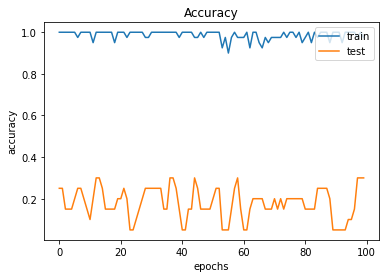

In [ ]:
from matplotlib import pyplot as plt 

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()

In [ ]:
history = classifier.fit(Training_set, epochs=200, validation_data=test_set)

Epoch 1/200
1/1 [==============================] - 2s 2s/step - loss: 4.1779e-04 - accuracy: 1.0000 - val_loss: 4.1929 - val_accuracy: 0.2000
Epoch 2/200
1/1 [==============================] - 2s 2s/step - loss: 3.1085e-04 - accuracy: 1.0000 - val_loss: 4.1710 - val_accuracy: 0.2000
Epoch 3/200
1/1 [==============================] - 2s 2s/step - loss: 3.9615e-04 - accuracy: 1.0000 - val_loss: 4.1819 - val_accuracy: 0.2000
Epoch 4/200
1/1 [==============================] - 2s 2s/step - loss: 3.5399e-04 - accuracy: 1.0000 - val_loss: 4.2183 - val_accuracy: 0.2000
Epoch 5/200
1/1 [==============================] - 2s 2s/step - loss: 1.8444e-04 - accuracy: 1.0000 - val_loss: 4.2633 - val_accuracy: 0.2000
Epoch 6/200
1/1 [==============================] - 2s 2s/step - loss: 1.7372e-04 - accuracy: 1.0000 - val_loss: 4.3131 - val_accuracy: 0.2000
Epoch 7/200
1/1 [==============================] - 2s 2s/step - loss: 7.9304e-04 - accuracy: 1.0000 - val_loss: 4.4156 - val_accuracy: 0.1500
Epoch 

In [ ]:
test_loss, test_accuracy = classifier.evaluate(test_set)

1/1 [==============================] - 0s 319ms/step - loss: 6.6021 - accuracy: 0.1500


In [ ]:
test_loss

6.602138519287109

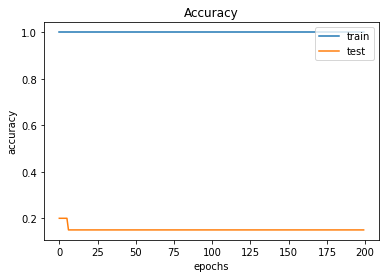

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()


In [ ]:
history = classifier.fit(Training_set, epochs=300, validation_data=test_set)

Epoch 1/300
1/1 [==============================] - 2s 2s/step - loss: 7.5182e-05 - accuracy: 1.0000 - val_loss: 6.6471 - val_accuracy: 0.1500
Epoch 2/300
1/1 [==============================] - 2s 2s/step - loss: 3.2983e-05 - accuracy: 1.0000 - val_loss: 6.6799 - val_accuracy: 0.1500
Epoch 3/300
1/1 [==============================] - 2s 2s/step - loss: 3.7896e-05 - accuracy: 1.0000 - val_loss: 6.7087 - val_accuracy: 0.1500
Epoch 4/300
1/1 [==============================] - 2s 2s/step - loss: 1.1408e-05 - accuracy: 1.0000 - val_loss: 6.7325 - val_accuracy: 0.1500
Epoch 5/300
1/1 [==============================] - 2s 2s/step - loss: 3.5493e-05 - accuracy: 1.0000 - val_loss: 6.7632 - val_accuracy: 0.1500
Epoch 6/300
1/1 [==============================] - 2s 2s/step - loss: 2.1659e-04 - accuracy: 1.0000 - val_loss: 6.7416 - val_accuracy: 0.1500
Epoch 7/300
1/1 [==============================] - 2s 2s/step - loss: 8.9678e-04 - accuracy: 1.0000 - val_loss: 6.8546 - val_accuracy: 0.1500
Epoch 

In [ ]:
test_loss, test_accuracy = classifier.evaluate(test_set)

1/1 [==============================] - 0s 320ms/step - loss: 6.0129 - accuracy: 0.1000


In [ ]:
test_loss

6.01291036605835

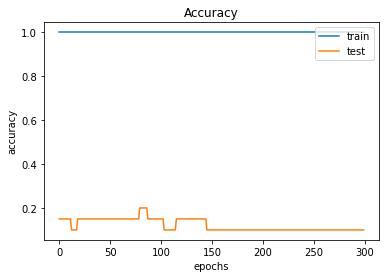

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'test'], loc = 'upper right')
plt.show()